In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import sys

sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/")

from analysis.utils import load_sweep_metadata, load_data
import pandas as pd
import torch


## At some point 

In [3]:
from common.latent_projector import LatentProjector
from common.nonlinear_latent_projector import NonlinearLatentProjector, SupervisedNonlinearLatentProjector

In [4]:
from tqdm import tqdm
from envs import make_env
from hydra import initialize, compose
from omegaconf import OmegaConf
from common.parser import parse_cfg
from common.seed import set_seed

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied



In [5]:
from tdmpc2 import TDMPC2

In [6]:
# Base configuration for state-based environment
CKPT_TO_USE = 500_000
CKPT_PATH_STATE = f'logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/{CKPT_TO_USE}.pt'
CKPT_PATH_RGB = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2026-01-15/21-56-52/cartpole_exp_pixel/models/650000.pt'

override_cfg_state = dict(
    task='cartpole-swingup',
    checkpoint=CKPT_PATH_STATE,
    obs='state',
    seed=0,
    compile=False,
    mpc=True,
    multitask=False,
    model_size=5,
    save_video=False,
    record_planning=False,
)

override_cfg_rgb = dict(
    task='cartpole-swingup',
    checkpoint=CKPT_PATH_RGB,
    obs='rgb',
    seed=0,
    compile=False,
    mpc=True,
    multitask=False,
    model_size=5,
    save_video=False,
    record_planning=False,
)

# Create RGB-based environment
with initialize(config_path="tdmpc2", version_base=None):
    cfg_rgb = compose(config_name="config")
    OmegaConf.set_struct(cfg_rgb, False)
    cfg_rgb = OmegaConf.merge(cfg_rgb, override_cfg_rgb)

cfg_rgb = parse_cfg(cfg_rgb)
set_seed(cfg_rgb.seed)

cfg_rgb.initial_state = {
    'qpos': {
        'slider': 0,
        'hinge_1': 0,
    },
}

env_rgb = make_env(cfg_rgb)

print("\nLoading RGB-based agent...")
agent_rgb = TDMPC2(cfg_rgb)
if hasattr(cfg_rgb, 'checkpoint') and cfg_rgb.checkpoint:
    print(f"Loading checkpoint: {cfg_rgb.checkpoint}")
    agent_rgb.load(cfg_rgb.checkpoint)

# Create state-based environment
with initialize(config_path="tdmpc2", version_base=None):
    cfg_state = compose(config_name="config")
    OmegaConf.set_struct(cfg_state, False)
    cfg_state = OmegaConf.merge(cfg_state, override_cfg_state)

cfg_state = parse_cfg(cfg_state)
set_seed(cfg_state.seed)

cfg_state.initial_state = {
    'qpos': {
        'slider': 0,
        'hinge_1': 0,
    },
}

env_state = make_env(cfg_state)

print("\nLoading state-based agent...")
agent_state = TDMPC2(cfg_state)
if hasattr(cfg_state, 'checkpoint') and cfg_state.checkpoint:
    print(f"Loading checkpoint: {cfg_state.checkpoint}")
    agent_state.load(cfg_state.checkpoint)



Loading RGB-based agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: /home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2026-01-15/21-56-52/cartpole_exp_pixel/models/650000.pt

Loading state-based agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/500000.pt


In [9]:
def sample_uniform_obs(n):
    """
    Sample n observations uniformly from the following bounds:
    - position:         [-1.5, 1.5]
    - cos:              [-1.0, 1.0]
    - sin:              [-1.0, 1.0]
    - art velocity:     [-2.5, 2.5]
    - angular velocity: [-7.5, 7.5]
    Returns:
        obs: numpy array of shape [n, 5]
    """
    bounds = np.array([
        [-1.5, 1.5],  # position
        [0, 360],  # angle
        #[-1.0, 1.0],  # cos
        #[-1.0, 1.0],  # sin
        [-2.5, 2.5],  # cart velocity
        [-7.5, 7.5],  # angular velocity
    ])
    obs = np.random.uniform(bounds[:, 0],
                            bounds[:, 1],
                            size=(n, bounds.shape[0]))
    return obs


number_of_samples = 30_000
obs_uniform_angle = sample_uniform_obs(number_of_samples)


In [10]:
obs_uniform = np.zeros((number_of_samples, 5))
obs_uniform[:, 0] = obs_uniform_angle[:, 0]
obs_uniform[:, 1] = np.cos(np.deg2rad(obs_uniform_angle[:, 1]))
obs_uniform[:, 2] = np.sin(np.deg2rad(obs_uniform_angle[:, 1]))
obs_uniform[:, 3] = obs_uniform_angle[:, 2]
obs_uniform[:, 4] = obs_uniform_angle[:, 3]


In [11]:
np.save(
    '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/data_generation/obs_uniform_30k.npy',
    obs_uniform)

In [9]:
obs_uniform_torch = torch.from_numpy(obs_uniform).to('cuda').float()
z_torch = agent_state.model.encode(obs_uniform_torch, task=None).detach().cpu()

In [17]:
save_directory = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data'

train_idx = int(0.8 * len(z_torch))
train_latents = z_torch[:train_idx]
test_latents = z_torch[train_idx:]
train_states = obs_uniform_torch[:train_idx]
test_states = obs_uniform_torch[train_idx:]
for k in [3, 10]:
    print(f"\n=== Fitting NonlinearLatentProjector with k={k} ===")
    projector = SupervisedNonlinearLatentProjector.fit(
        train_latents,
        test_latents,
        train_states,
        test_states,
        k=k,
        alpha=0.7,
        hidden_dims=[256, 128],
        epochs=2000,
        early_stopping_patience=100,
    )
    path = f"{save_directory}/state_supervised_nonlinear_projector_k{k}.pt"
    projector.save(path)
    print(f"Saved nonlinear projector with k={k} to {path}")


=== Fitting NonlinearLatentProjector with k=3 ===


Fitting supervised k=3:  19%|█▉        | 389/2000 [01:27<06:02,  4.45it/s, loss=0.0513, recon=0.0593, state=0.0325, test=0.0536]



Early stopping at epoch 390
SupervisedNonlinearLatentProjector.fit: k=3, alpha=0.7
  Reconstruction: train_R²=0.9460, test_R²=0.9431
  State pred:     train_R²=0.9705, test_R²=0.9687
  (N_train=24000, N_test=6000)
SupervisedNonlinearLatentProjector saved to /home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data/state_supervised_nonlinear_projector_k3.pt
Saved nonlinear projector with k=3 to /home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data/state_supervised_nonlinear_projector_k3.pt

=== Fitting NonlinearLatentProjector with k=10 ===


Fitting supervised k=10: 100%|██████████| 2000/2000 [07:29<00:00,  4.45it/s, loss=0.0014, recon=0.0020, state=0.0000, test=0.0015]

SupervisedNonlinearLatentProjector.fit: k=10, alpha=0.7
  Reconstruction: train_R²=0.9980, test_R²=0.9979
  State pred:     train_R²=1.0000, test_R²=1.0000
  (N_train=24000, N_test=6000)
SupervisedNonlinearLatentProjector saved to /home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data/state_supervised_nonlinear_projector_k10.pt
Saved nonlinear projector with k=10 to /home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data/state_supervised_nonlinear_projector_k10.pt


In [11]:
z_proj, h = projector.project_and_components(z_torch)
z_proj = z_proj.detach().cpu()
h = h.detach().cpu()
obs_uniform_torch_cpu = obs_uniform_torch.detach().cpu()

In [12]:
h

tensor([[-0.9938,  0.8000, -0.5359, -1.3009],
        [-2.2849,  0.3507,  0.1296, -1.0172],
        [ 0.6035, -0.3405,  1.6656, -0.3097],
        ...,
        [-0.9464,  0.3159, -0.3063, -0.6274],
        [ 1.3415,  0.3387, -1.9066, -1.1330],
        [ 0.7647,  2.5668, -2.9885, -1.3147]])

In [13]:
z_proj.shape, h.shape

(torch.Size([30000, 512]), torch.Size([30000, 4]))

In [14]:
obs_uniform_torch.shape

torch.Size([30000, 5])

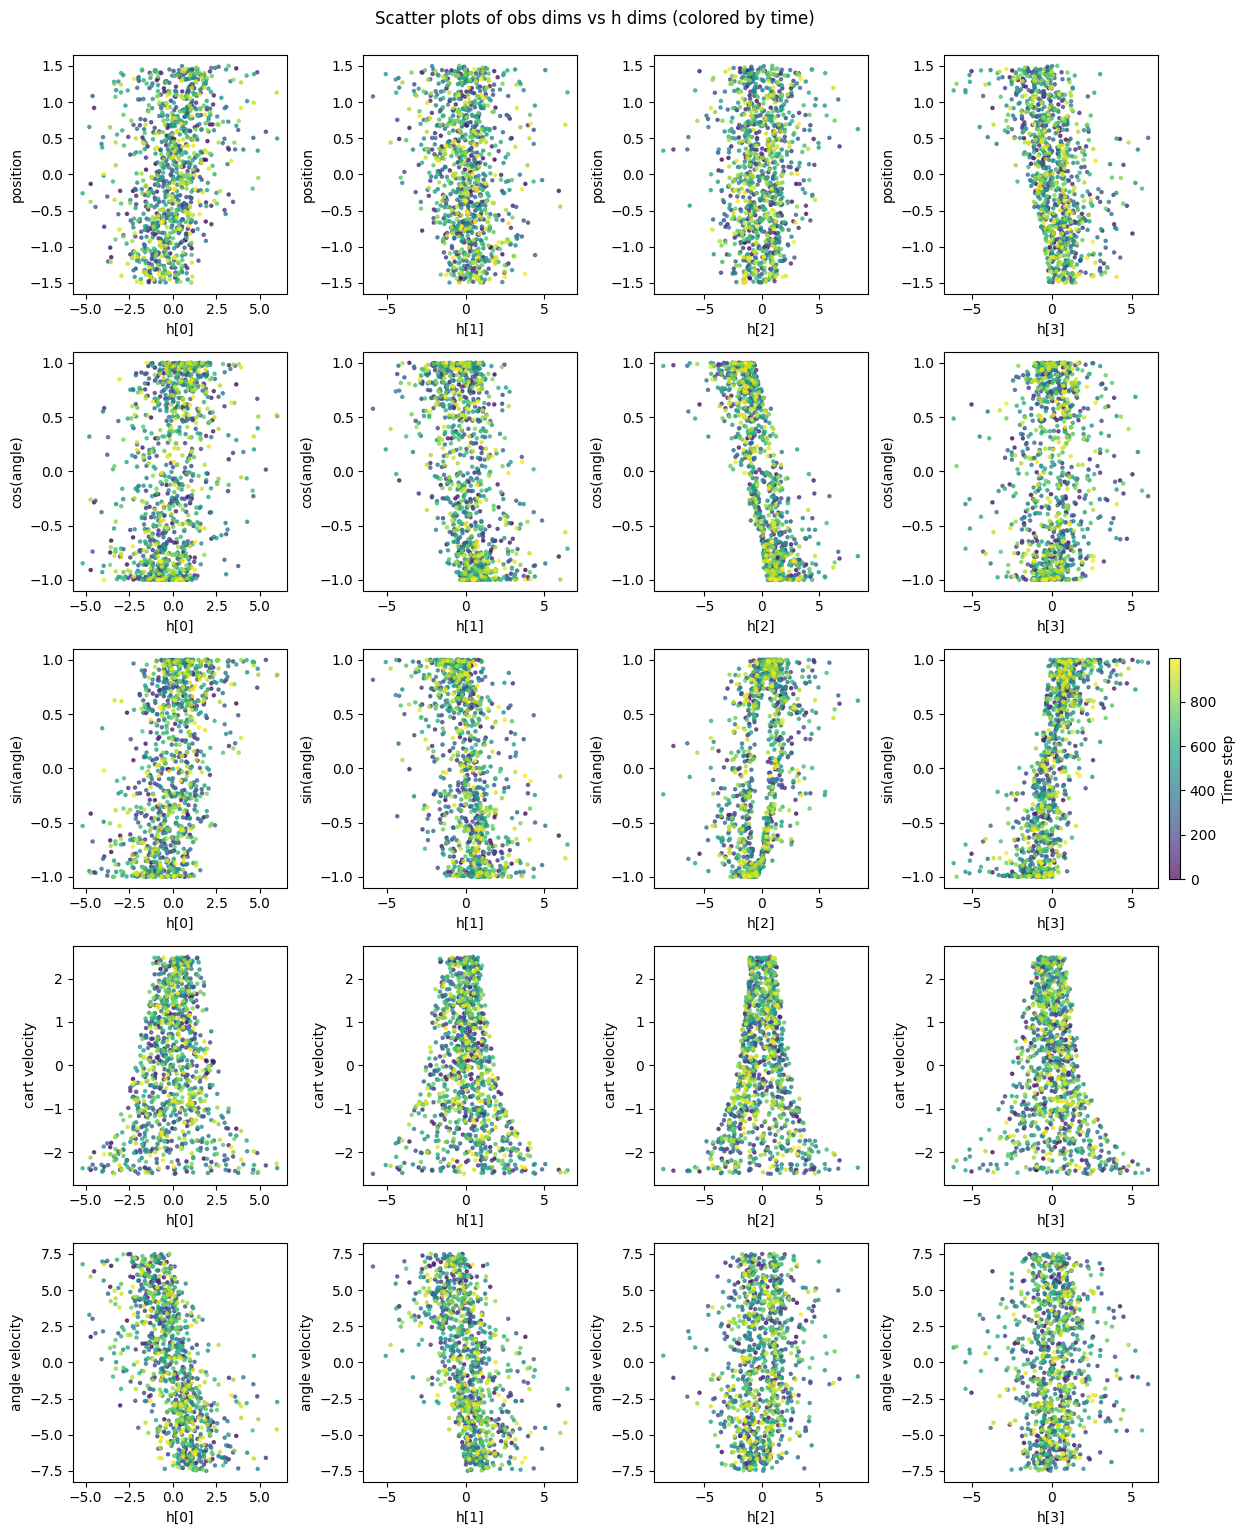

In [15]:
import matplotlib.pyplot as plt

obs_variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angle velocity'
}

episode = 4
obs_plot = obs_uniform_torch_cpu[:1000]
h_plot = h[:1000]

num_obs_dim = obs_plot.shape[1]
num_h_dim = h_plot.shape[1]

# We'll color points by time
cmap = plt.get_cmap("viridis")
times = np.arange(obs_plot.shape[0])

plt.figure(figsize=(3 * num_h_dim, 3 * num_obs_dim))

for i in range(num_obs_dim):
    for j in range(num_h_dim):
        plt.subplot(num_obs_dim, num_h_dim, i * num_h_dim + j + 1)
        x = h_plot[:, j].cpu() if hasattr(h_plot[:, j], 'cpu') else h_plot[:, j]
        y = obs_plot[:, i]
        sc = plt.scatter(x, y, c=times, cmap=cmap, s=5, alpha=0.7)
        plt.xlabel(f'h[{j}]')
        plt.ylabel(f'{obs_variable_names[i]}')
        plt.tight_layout()

plt.suptitle("Scatter plots of obs dims vs h dims (colored by time)", y=1.02)
cbar = plt.colorbar(sc,
                    ax=plt.gcf().get_axes(),
                    orientation='vertical',
                    fraction=0.01,
                    pad=0.01)
cbar.set_label('Time step')
plt.show()